# Stage 3 — Blind Expert Evaluation: Figures

Produces **three publication-quality figures** for the manuscript:

- **Figure A** — Diverging stacked bar: RAG+/Tie/RAG− distribution per reviewer × dimension  
- **Figure B** — Correctness vs. Clarity dissociation scatter (the expertise gradient in 2D)  
- **Figure C** — Annotation depth per reviewer: annotated vs. unannotated non-tie preferences  

Figure A is the primary candidate for the manuscript. Figure B and C are supplementary or discussion support.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Output path ────────────────────────────────────────────────────────────────
DATA_PATH   = r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\evaluators_responses.txt"
OUTPUT_DIR  = r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper"

# ── Global style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':      'Arial',
    'font.size':        10,
    'axes.linewidth':   0.8,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       150,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
})

# ── Colour palette (colourblind-safe) ─────────────────────────────────────────
C_RAGPLUS  = '#2166AC'   # blue  — RAG+
C_TIE      = '#D9D9D9'   # grey  — Tie
C_RAGMINUS = '#D6604D'   # red   — RAG−

## 1. Load and resolve data

In [2]:
df = pd.read_csv(DATA_PATH)
df = df[df['reviewer'] != 'reviewer'].reset_index(drop=True)   # drop duplicate header row
df.columns = df.columns.str.strip()

for col in ['scientific_clarity','factual_correctness','confidence','rag_plus_pos','reviewer']:
    df[col] = df[col].astype(str).str.strip()

def resolve(choice, rag_plus_pos):
    if choice == 'Tie':          return 'Tie'
    elif choice == rag_plus_pos: return 'RAG+'
    else:                        return 'RAG-'

df['clarity_r']     = df.apply(lambda r: resolve(r['scientific_clarity'],  r['rag_plus_pos']), axis=1)
df['correctness_r'] = df.apply(lambda r: resolve(r['factual_correctness'], r['rag_plus_pos']), axis=1)

# ── Reviewer ordering: expertise low → high (PI last, separate)
REVIEWER_ORDER = [
    'Guillaume Henderson',
    'Yaiza Gonzalez Garcia',
    'Sviatlana Lamaka',
    'Alexandre Bastos',
    'PI (Admin)',
]
REVIEWER_LABELS = [
    'Henderson\n(non-expert)',
    'Gonzalez Garcia\n(adjacent, SECM)',
    'Lamaka\n(SVET specialist)',
    'Bastos\n(SVET specialist)',
    'PI*\n(SVET specialist)',
]

print('Rows:', len(df))
print(df['reviewer'].value_counts())

Rows: 147
reviewer
PI (Admin)               42
Guillaume Henderson      42
Alexandre Bastos         21
Sviatlana Lamaka         21
Yaiza Gonzalez Garcia    21
Name: count, dtype: int64


## 2. Helper — compute proportions per reviewer

In [3]:
def get_props(reviewer, col):
    """Return (n_plus, n_tie, n_minus, total) for one reviewer and one resolved column."""
    sub = df[df['reviewer'] == reviewer]
    n   = len(sub)
    n_plus  = (sub[col] == 'RAG+').sum()
    n_tie   = (sub[col] == 'Tie').sum()
    n_minus = (sub[col] == 'RAG-').sum()
    return int(n_plus), int(n_tie), int(n_minus), int(n)

# Quick sanity check
for r in REVIEWER_ORDER:
    p, t, m, n = get_props(r, 'correctness_r')
    print(f"{r:<25} correctness  RAG+={p:2d} Tie={t:2d} RAG-={m:2d}  (n={n})")

Guillaume Henderson       correctness  RAG+= 6 Tie=30 RAG-= 6  (n=42)
Yaiza Gonzalez Garcia     correctness  RAG+= 8 Tie= 3 RAG-=10  (n=21)
Sviatlana Lamaka          correctness  RAG+=11 Tie= 6 RAG-= 4  (n=21)
Alexandre Bastos          correctness  RAG+=13 Tie= 5 RAG-= 3  (n=21)
PI (Admin)                correctness  RAG+=35 Tie= 1 RAG-= 6  (n=42)


---
## Figure A — Diverging stacked bar: preference distribution per reviewer × dimension

**Layout**: Two panels side by side (Factual Correctness | Scientific Clarity).  
Each panel has one bar per reviewer.  
Bars are diverging: RAG+ extends right (blue), RAG− extends left (red), Tie is the central grey block.  
Counts printed inside each segment when wide enough.

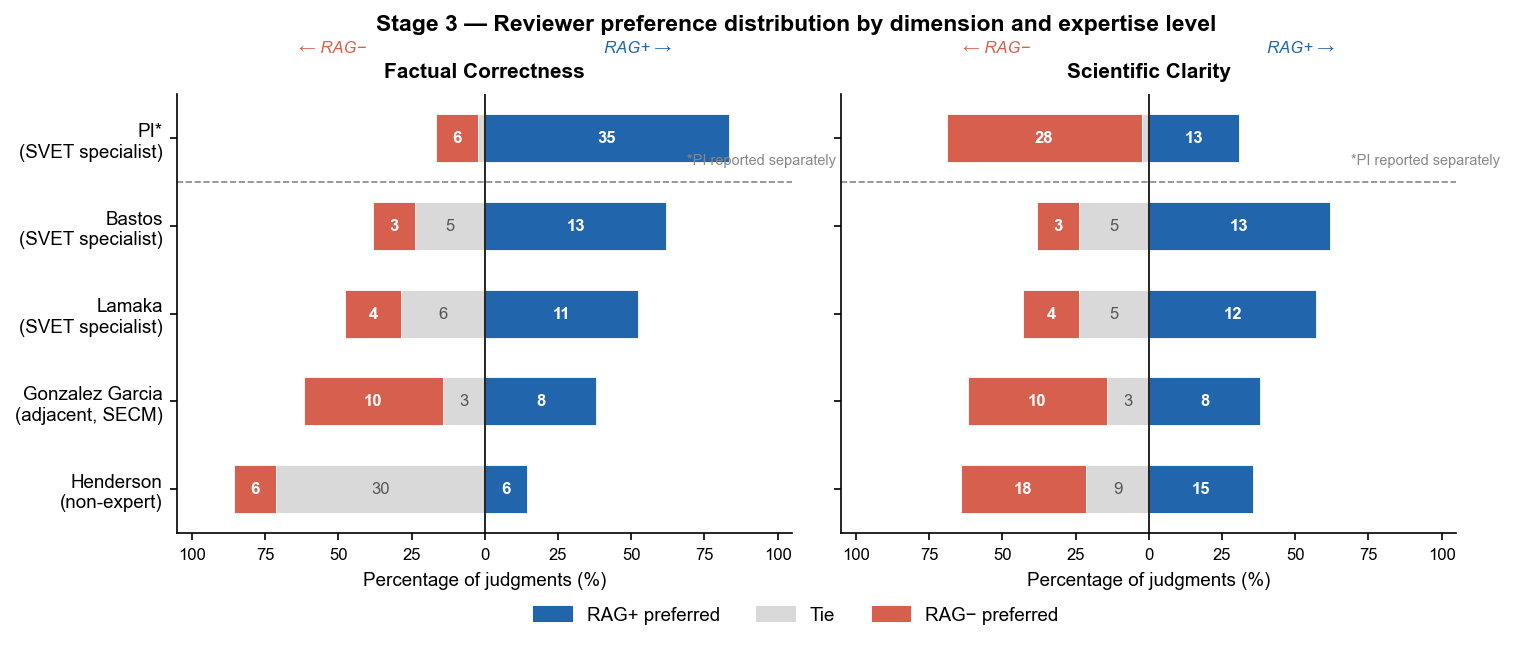

Figure A saved.


In [4]:
def diverging_bars(ax, reviewer_order, reviewer_labels, col, title, show_ylabel=True):
    """
    Draw a horizontal diverging stacked bar chart.
    RAG+ → right (blue), Tie → centre (grey), RAG− → left (red).
    Bars are normalised to 100%.
    """
    data = []
    for rev in reviewer_order:
        p, t, m, n = get_props(rev, col)
        data.append({'RAG+': p/n*100, 'Tie': t/n*100, 'RAG-': m/n*100,
                     'n_plus': p, 'n_tie': t, 'n_minus': m, 'n': n})

    y = np.arange(len(reviewer_order))
    bar_h = 0.55

    for i, d in enumerate(data):
        # RAG+ (right of centre)
        ax.barh(i, d['RAG+'], height=bar_h, left=0,
                color=C_RAGPLUS,  edgecolor='white', linewidth=0.4)
        # Tie (centred at 0 → extends left from RAG+ edge... instead stack: Tie left of RAG+)
        # Convention: RAG+ | Tie | RAG-  reading right to left from 0
        # We'll anchor at 0 and go: RAG+ positive, then Tie and RAG- negative
        ax.barh(i, -d['Tie'],   height=bar_h, left=0,
                color=C_TIE,     edgecolor='white', linewidth=0.4)
        ax.barh(i, -d['RAG-'],  height=bar_h, left=-d['Tie'],
                color=C_RAGMINUS,edgecolor='white', linewidth=0.4)

        # Annotations: counts inside bars (skip if segment < 8%)
        fontsize = 8
        if d['RAG+'] >= 8:
            ax.text(d['RAG+']/2, i, str(d['n_plus']),
                    ha='center', va='center', fontsize=fontsize, color='white', fontweight='bold')
        if d['Tie'] >= 8:
            ax.text(-d['Tie']/2, i, str(d['n_tie']),
                    ha='center', va='center', fontsize=fontsize, color='#555555')
        if d['RAG-'] >= 8:
            ax.text(-d['Tie']-d['RAG-']/2, i, str(d['n_minus']),
                    ha='center', va='center', fontsize=fontsize, color='white', fontweight='bold')

    # Axes formatting
    ax.set_yticks(y)
    if show_ylabel:
        ax.set_yticklabels(reviewer_labels, fontsize=9)
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-105, 105)
    ax.set_xlabel('Percentage of judgments (%)', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    ax.axvline(0, color='black', linewidth=0.8)

    # X-axis labels: show absolute values
    xticks = [-100, -75, -50, -25, 0, 25, 50, 75, 100]
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(abs(x)) for x in xticks], fontsize=8)

    # Direction labels
    ax.text(-52, len(reviewer_order)-0.05, '← RAG−', ha='center', va='bottom',
            fontsize=8, color=C_RAGMINUS, style='italic')
    ax.text( 52, len(reviewer_order)-0.05, 'RAG+ →', ha='center', va='bottom',
            fontsize=8, color=C_RAGPLUS,  style='italic')

    # PI separator line
    ax.axhline(3.5, color='#888888', linewidth=0.8, linestyle='--')
    ax.text(120, 3.7, '*PI reported separately', fontsize=7, color='#888888', ha='right')


# ── Draw Figure A ──────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
fig.subplots_adjust(wspace=0.08)

diverging_bars(ax1, REVIEWER_ORDER, REVIEWER_LABELS, 'correctness_r',
               'Factual Correctness', show_ylabel=True)
diverging_bars(ax2, REVIEWER_ORDER, REVIEWER_LABELS, 'clarity_r',
               'Scientific Clarity',  show_ylabel=False)

# Shared legend
handles = [
    mpatches.Patch(color=C_RAGPLUS,  label='RAG+ preferred'),
    mpatches.Patch(color=C_TIE,      label='Tie'),
    mpatches.Patch(color=C_RAGMINUS, label='RAG− preferred'),
]
fig.legend(handles=handles, loc='lower center', ncol=3,
           frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.08))

fig.suptitle('Stage 3 — Reviewer preference distribution by dimension and expertise level',
             fontsize=11, fontweight='bold', y=1.02)

#fig.savefig(OUTPUT_DIR + r'\figureA_stage3_diverging.png', bbox_inches='tight')

plt.show()
print('Figure A saved.')

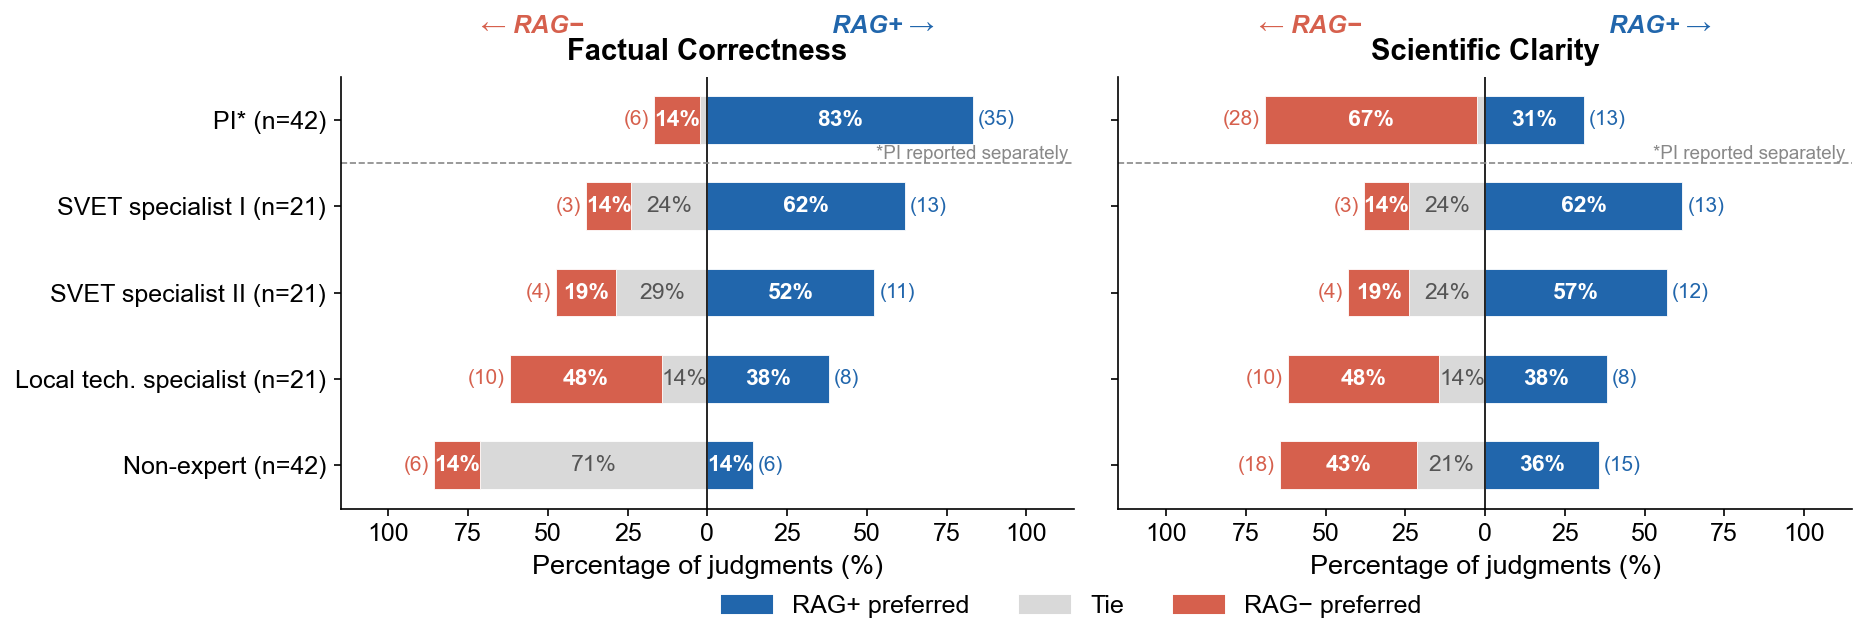

Figure A saved.


In [5]:
REVIEWER_LABELS = [
    'Non-expert (n=42)',
    'Local tech. specialist (n=21)',
    'SVET specialist II (n=21)',
    'SVET specialist I (n=21)',
    'PI* (n=42)',
]

# ── Font sizes ──────────────────────────────────────────────────────────────
FS_BAR_PCT        = 11   # % labels inside bars
FS_BAR_COUNT      = 10   # raw counts outside bars
FS_YTICKS         = 12   # reviewer labels
FS_XLABEL         = 13   # "Percentage of judgments (%)"
FS_TITLE          = 14   # panel titles
FS_XTICKS         = 12   # x-axis tick labels
FS_DIRECTION      = 12   # ← RAG− / RAG+ →
FS_PI_NOTE        = 9   # "*PI reported separately"
FS_LEGEND         = 12   # bottom legend

def diverging_bars(ax, reviewer_order, reviewer_labels, col, title, show_ylabel=True):
    data = []
    for rev in reviewer_order:
        p, t, m, n = get_props(rev, col)
        data.append({'RAG+': p/n*100, 'Tie': t/n*100, 'RAG-': m/n*100,
                     'n_plus': p, 'n_tie': t, 'n_minus': m, 'n': n})

    y     = np.arange(len(reviewer_order))
    bar_h = 0.55

    for i, d in enumerate(data):
        ax.barh(i,  d['RAG+'],          height=bar_h, left=0,
                color=C_RAGPLUS,  edgecolor='white', linewidth=0.4)
        ax.barh(i, -d['Tie'],           height=bar_h, left=0,
                color=C_TIE,      edgecolor='white', linewidth=0.4)
        ax.barh(i, -d['RAG-'],          height=bar_h, left=-d['Tie'],
                color=C_RAGMINUS, edgecolor='white', linewidth=0.4)

        # ── Labels: show % inside bar, skip if segment < 8 pp ─────────────────
        fs = FS_BAR_PCT
        if d['RAG+'] >= 8:
            ax.text(d['RAG+']/2, i, f"{d['RAG+']:.0f}%",
                    ha='center', va='center', fontsize=fs,
                    color='white', fontweight='bold')
        if d['Tie'] >= 8:
            ax.text(-d['Tie']/2, i, f"{d['Tie']:.0f}%",
                    ha='center', va='center', fontsize=fs, color='#555555')
        if d['RAG-'] >= 8:
            ax.text(-d['Tie'] - d['RAG-']/2, i, f"{d['RAG-']:.0f}%",
                    ha='center', va='center', fontsize=fs,
                    color='white', fontweight='bold')

        # ── Raw counts as small annotations outside bars ───────────────────────
        # Right side: RAG+ count
        ax.text(d['RAG+'] + 1.5, i, f"({d['n_plus']})",
            ha='left', va='center', fontsize=FS_BAR_COUNT, color=C_RAGPLUS)
        # Left side: RAG- count (only if non-zero)
        if d['n_minus'] > 0:
            ax.text(-d['Tie'] - d['RAG-'] - 1.5, i, f"({d['n_minus']})",
                ha='right', va='center', fontsize=FS_BAR_COUNT, color=C_RAGMINUS)

    # Axes
    ax.set_yticks(y)
    if show_ylabel:
        ax.set_yticklabels(reviewer_labels, fontsize=FS_YTICKS)
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-115, 115)
    ax.set_xlabel('Percentage of judgments (%)', fontsize=FS_XLABEL)
    ax.set_title(title, fontsize=FS_TITLE, fontweight='bold', pad=8)
    ax.axvline(0, color='black', linewidth=0.8)

    xticks = [-100, -75, -50, -25, 0, 25, 50, 75, 100]
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(abs(x)) for x in xticks], fontsize=FS_XTICKS)

    ax.text(-55, len(reviewer_order) - 0.05, '← RAG−',
        ha='center', va='bottom', fontsize=FS_DIRECTION, color=C_RAGMINUS,
        style='italic', fontweight='bold')
    ax.text( 55, len(reviewer_order) - 0.05, 'RAG+ →',
        ha='center', va='bottom', fontsize=FS_DIRECTION, color=C_RAGPLUS,
        style='italic', fontweight='bold')

    ax.axhline(3.5, color='#888888', linewidth=0.8, linestyle='--')
    ax.text(113, 3.55, '*PI reported separately',
        fontsize=FS_PI_NOTE, color='#888888', ha='right')


# ── Draw ───────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.0), sharey=False)
fig.subplots_adjust(wspace=0.06, bottom=0.16)

diverging_bars(ax1, REVIEWER_ORDER, REVIEWER_LABELS, 'correctness_r',
               'Factual Correctness', show_ylabel=True)
diverging_bars(ax2, REVIEWER_ORDER, REVIEWER_LABELS, 'clarity_r',
               'Scientific Clarity',  show_ylabel=False)

handles = [
    mpatches.Patch(color=C_RAGPLUS,  label='RAG+ preferred'),
    mpatches.Patch(color=C_TIE,      label='Tie'),
    mpatches.Patch(color=C_RAGMINUS, label='RAG− preferred'),
]
fig.legend(handles=handles, loc='lower center', ncol=3,
           frameon=False, fontsize=FS_LEGEND, bbox_to_anchor=(0.5, -0.06))
#fig.suptitle(
 #   'Stage 3 — Reviewer preference distribution by dimension and expertise level',
  #  fontsize=11, fontweight='bold', y=1.02)

fig.savefig(OUTPUT_DIR + r'\figureA_stage3_diverging.png', bbox_inches='tight')
plt.show()
print('Figure A saved.')

---
## Figure B — Correctness vs. Clarity 2D scatter (the expertise gradient)

Each reviewer is a point.  
X-axis = RAG+ share of non-tie **correctness** judgments.  
Y-axis = RAG+ share of non-tie **clarity** judgments.  
The diagonal (x=y) is the iso-preference line: points above it prefer RAG+ more on clarity than correctness.  
The quadrants reveal the correctness/clarity dissociation pattern.

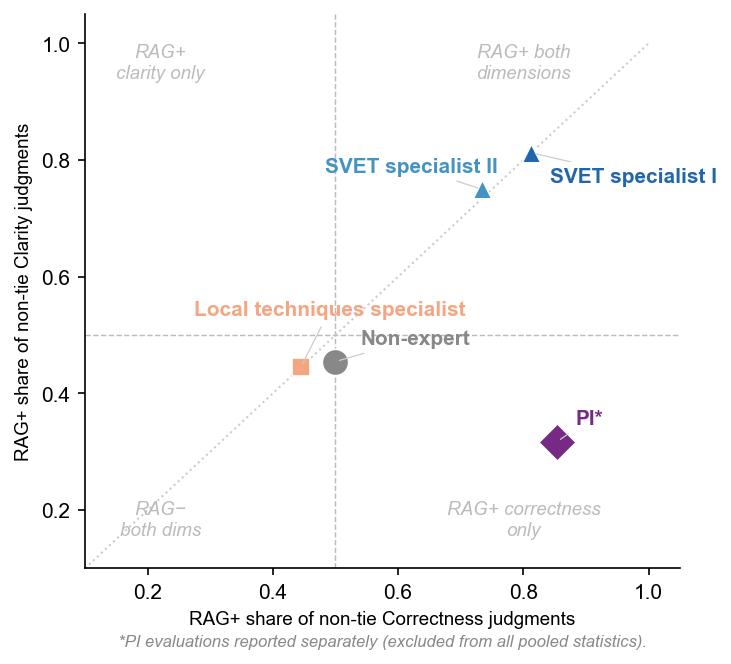

Figure B saved.

PI coordinates: x=0.854, y=0.317


In [7]:

# ── RAG+ shares of non-tie judgments ──────────────────────────────────────────
# Correctness: RAG+ / (RAG+ + RAG−)
corr_shares = {
    'Guillaume Henderson':   6 / 12,
    'Yaiza Gonzalez Garcia': 8 / 18,
    'Sviatlana Lamaka':      11 / 15,
    'Alexandre Bastos':      13 / 16,
    'PI (Admin)':            35 / 41,
}

# Clarity: RAG+ / (RAG+ + RAG−)
clar_shares = {
    'Guillaume Henderson':   15 / 33,
    'Yaiza Gonzalez Garcia': 8 / 18,
    'Sviatlana Lamaka':      12 / 16,
    'Alexandre Bastos':      13 / 16,
    'PI (Admin)':            13 / 41,
}

# ── n per reviewer (for marker sizing) ────────────────────────────────────────
n_map = {
    'Guillaume Henderson':          42,
    'Yaiza Gonzalez Garcia': 21,
    'Sviatlana Lamaka':      21,
    'Alexandre Bastos':      21,
    'PI (Admin)':            42,
}

# Base size = 80 for n=21; scale linearly so n=42 → 160
def marker_size(rev):
    return 80 * (n_map[rev] / 21)

# ── Reviewer styling — remove hardcoded size, compute dynamically ──────────────
marker_map = {
    'Guillaume Henderson':          ('o', '#888888', 'non-expert'),
    'Yaiza Gonzalez Garcia':('s', '#F4A582', 'local techniques specialist'),
    'Sviatlana Lamaka':     ('^', '#4393C3', 'SVET specialist'),
    'Alexandre Bastos':     ('^', '#2166AC', 'SVET specialist'),
    'PI (Admin)':           ('D', '#762A83', 'PI (reported separately)'),
}

label_offset = {
    'Guillaume Henderson':           ( 0.04,  0.03),
    'Yaiza Gonzalez Garcia': (-0.17,  0.09),
    'Sviatlana Lamaka':      (-0.25,  0.03),
    'Alexandre Bastos':      ( 0.03, -0.05),
    'PI (Admin)':            ( 0.03,  0.03),
}

short_names = {
    'Guillaume Henderson':           'Non-expert',
    'Yaiza Gonzalez Garcia': 'Local techniques specialist',
    'Sviatlana Lamaka':      'SVET specialist II',
    'Alexandre Bastos':      'SVET specialist I',
    'PI (Admin)':            'PI*',
}

# ── Draw ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4.5))

ax.set_xlim(0.10, 1.05)
ax.set_ylim(0.10, 1.05)

ax.axhline(0.5, color='#BBBBBB', linewidth=0.7, linestyle='--', zorder=0)
ax.axvline(0.5, color='#BBBBBB', linewidth=0.7, linestyle='--', zorder=0)
ax.plot([0.1, 1.0], [0.1, 1.0], color='#CCCCCC', linewidth=1.0,
        linestyle=':', zorder=0)

ax.text(0.22, 1, 'RAG+\nclarity only',     fontsize=9, color='#BBBBBB',
        ha='center', va='top',    style='italic')
ax.text(0.80, 1, 'RAG+ both\ndimensions',  fontsize=9, color='#BBBBBB',
        ha='center', va='top',    style='italic')
ax.text(0.22, 0.15, 'RAG−\nboth dims',        fontsize=9, color='#BBBBBB',
        ha='center', va='bottom', style='italic')
ax.text(0.80, 0.15, 'RAG+ correctness\nonly', fontsize=9, color='#BBBBBB',
        ha='center', va='bottom', style='italic')

legend_handles = {}
EXTERNAL = [r for r in REVIEWER_ORDER if r != 'PI (Admin)']

for rev in EXTERNAL + ['PI (Admin)']:
    x     = corr_shares[rev]
    y_val = clar_shares[rev]
    marker, color, exp_label = marker_map[rev]
    size  = marker_size(rev)          # ← scaled by n
    zorder = 5 if rev == 'PI (Admin)' else 3

    ax.scatter(x, y_val, marker=marker, color=color, s=size,
               edgecolors='white', linewidths=0.8, zorder=zorder)

    if exp_label not in legend_handles:
        legend_handles[exp_label] = plt.Line2D(
            [0], [0], marker=marker, color='w',
            markerfacecolor=color, markersize=8,
            label=exp_label)

    dx, dy = label_offset[rev]
    ax.annotate(
        short_names[rev],
        xy=(x, y_val),
        xytext=(x + dx, y_val + dy),
        fontsize=10, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='-', color='#CCCCCC', lw=0.6),
        zorder=6)

ax.set_xlabel('RAG+ share of non-tie Correctness judgments', fontsize=9)
ax.set_ylabel('RAG+ share of non-tie Clarity judgments',     fontsize=9)
#ax.set_title('Stage 3 — Correctness vs. Clarity preference\n'
 #            '(RAG+ share of non-tie judgments)',
  #           fontsize=10, fontweight='bold')

# ── Legend: add size note ──────────────────────────────────────────────────────
#iso_line = plt.Line2D([0], [0], color='#CCCCCC', linewidth=1.0,
                     # linestyle=':', ) #label='Iso-preference line (x = y)')
size_note = plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor='none', markeredgecolor='#AAAAAA',
                       markersize=6, label=r'Marker size $\propto$ n questions')
handles_list = list(legend_handles.values()) + [size_note]
#ax.legend(handles=handles_list, fontsize=9, loc='upper left',
 #         bbox_to_anchor=(0, 0.83),
  #        frameon=True, framealpha=0.92, edgecolor='#CCCCCC')

ax.text(0.5, -0.14,
        '*PI evaluations reported separately (excluded from all pooled statistics).',
        ha='center', fontsize=8, color='#888888',
        transform=ax.transAxes, style='italic')

fig.tight_layout()
fig.savefig(OUTPUT_DIR + r'\figureB_stage3_scatter.png', dpi=300, bbox_inches='tight')

plt.show()
print('Figure B saved.')
print(f"\nPI coordinates: x={corr_shares['PI (Admin)']:.3f}, y={clar_shares['PI (Admin)']:.3f}")